# Ablation — Full Model Quantization (all tensors)

Sweeps `quant_bits` ∈ {8, 6, 4} with `QUANTIZE_ALL=1` (1 seed).

| config | meaning |
|---|---|
| `bits = 8` | all tensors quantized to int8 (±127) |
| `bits = 6` | all tensors quantized to int6 (±31) stored in int8 container |
| `bits = 4` | all tensors quantized to int4 (±7) stored in int8 container |

In the baseline, small tensors (≤65,536 elements) and control tensors (`attn_scale`, `mlp_scale`, `resid_mix`, `q_gain`, `skip_weights`) bypass quantization and are kept in fp16/fp32. Here we remove that bypass and quantize **everything** — including these sensitive vectors — to measure their contribution to file size and BPB.

## Goal

This ablation answers two questions:
1. **How much additional file size do we save** by quantizing the small/control tensors, compared to only quantizing 2D matrices?
2. **How much BPB do we lose** from quantizing these sensitive parameters?

We compare these results against the 2D-matrices-only ablation to determine whether the extra savings justify the BPB cost.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import wandb
import importlib, utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

# Human-readable labels and display order
BITS_ORDER  = [8, 6, 4]
BITS_LABELS = {
    8:  "int8",
    6:  "int6",
    4:  "int4",
}
BITS_COLORS = {b: PALETTE[i] for i, b in enumerate(BITS_ORDER)}

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\matte\_netrc.


## Original Baseline (3 seeds, reference)

In [2]:
BASELINE_PREFIX = "golf_baseline_antonio_new"

baseline_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{BASELINE_PREFIX}"}},
))

baseline_rows = []
for run in baseline_runs:
    s = run.summary._json_dict
    baseline_rows.append({
        "seed":             run.config.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df_base = pd.DataFrame(baseline_rows).sort_values("seed").reset_index(drop=True)
BASE_BPB_MEAN  = df_base["final_val_bpb"].mean()
BASE_BPB_STD   = df_base["final_val_bpb"].std()
BASE_SIZE_MEAN = df_base["quant_file_bytes"].mean()

print("=" * 55)
print("ORIGINAL BASELINE  (3 seeds)")
print("=" * 55)
print(df_base.to_string(index=False))
print(f"\nfinal_val_bpb : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f}")
print(f"file size     : {BASE_SIZE_MEAN / 1e6:.2f} MB")
print("=" * 55)

ORIGINAL BASELINE  (3 seeds)
 seed  final_val_bpb  final_val_loss  quant_file_bytes
   42       1.311465        2.214354          15782427
  123       1.309002        2.210195          15785894
 1337       1.309833        2.211598          15776355

final_val_bpb : 1.3101 ± 0.0013
file size     : 15.78 MB


## Ablation — All Tensors Quantized

In [3]:
ABL_PREFIX = "ablation_full_quantization_correct"

abl_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL_PREFIX}"}},
))

rows = []
for run in abl_runs:
    s = run.summary._json_dict
    cfg = run.config
    bits = cfg.get("matrix_quant_bits", 8)

    # fp32 BPB: last val_bpb logged during training (before quantization)
    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    fp32_bpb = hist["val_bpb"].dropna().iloc[-1] if not hist.empty else None

    rows.append({
        "run_name": run.name,
        "matrix_quant_bits": bits,
        "label": BITS_LABELS.get(bits, str(bits)),
        "seed": cfg.get("seed"),
        "fp32_val_bpb": fp32_bpb,
        "final_val_bpb": s.get("final_val_bpb"),
        "final_val_loss": s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df = (
    pd.DataFrame(rows)
    .assign(bits_order=lambda d: d["matrix_quant_bits"].map({v: i for i, v in enumerate(BITS_ORDER)}))
    .sort_values("bits_order")
    .reset_index(drop=True)
    .drop(columns="bits_order")
)

# Compute delta (quantization damage)
df["delta_bpb"] = df["final_val_bpb"] - df["fp32_val_bpb"]

df_plot = (
    df.groupby("matrix_quant_bits", as_index=False)
    .agg(
        quant_file_bytes_median=("quant_file_bytes", "median"),
        quant_file_bytes_q25=("quant_file_bytes", lambda x: x.quantile(0.25)),
        quant_file_bytes_q75=("quant_file_bytes", lambda x: x.quantile(0.75)),
        final_val_bpb_median=("final_val_bpb", "median"),
        final_val_bpb_q25=("final_val_bpb", lambda x: x.quantile(0.25)),
        final_val_bpb_q75=("final_val_bpb", lambda x: x.quantile(0.75)),
        delta_bpb_median=("delta_bpb", "median"),
        delta_bpb_q25=("delta_bpb", lambda x: x.quantile(0.25)),
        delta_bpb_q75=("delta_bpb", lambda x: x.quantile(0.75)),
    )
    .assign(
        bits_order=lambda d: d["matrix_quant_bits"].map({v: i for i, v in enumerate(BITS_ORDER)}),
        label=lambda d: d["matrix_quant_bits"].map(BITS_LABELS),
    )
    .sort_values("bits_order")
    .reset_index(drop=True)
    .drop(columns="bits_order")
)

df_plot

,matrix_quant_bits,quant_file_bytes_median,quant_file_bytes_q25,quant_file_bytes_q75,final_val_bpb_median,final_val_bpb_q25,final_val_bpb_q75,delta_bpb_median,delta_bpb_q25,delta_bpb_q75,label
0,8,15731327.0,15726860.0,15733692.0,1.309628,1.308960,1.310322,0.004030,0.003785,0.004037,int8
1,6,11841303.0,11839526.0,11843290.5,1.370541,1.367591,1.371467,0.065698,0.062195,0.065715,int6
2,4,7781011.0,7780541.0,7782012.5,2.547363,2.546483,2.574200,1.241124,1.240699,1.267510,int4


### Compressed file size vs bitwidth

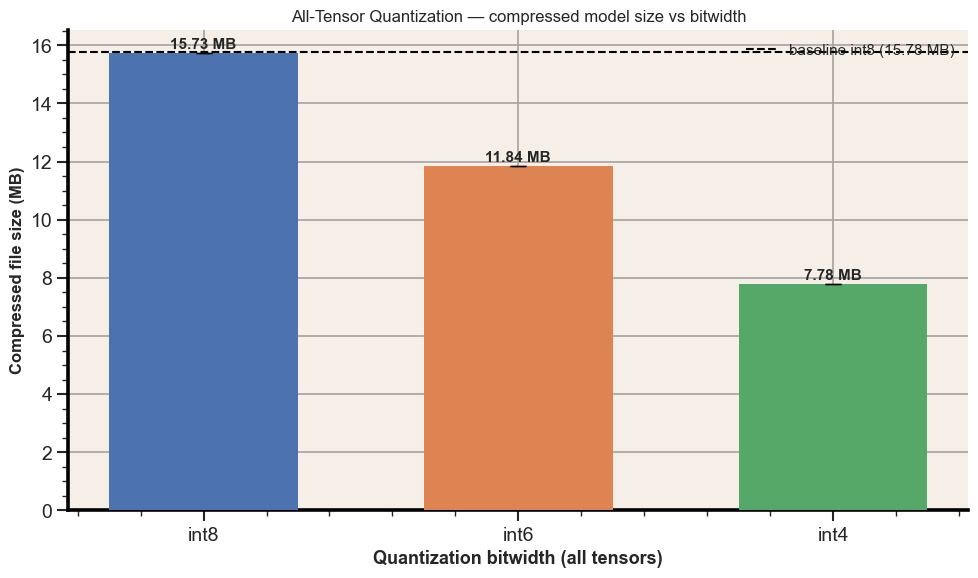

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

bits_vals = [b for b in BITS_ORDER if b in df_plot["matrix_quant_bits"].values]
sub = df_plot[df_plot["matrix_quant_bits"].isin(bits_vals)].set_index("matrix_quant_bits")

size_mb = [sub.loc[b, "quant_file_bytes_median"] / 1e6 for b in bits_vals]
size_q25 = [sub.loc[b, "quant_file_bytes_q25"] / 1e6 for b in bits_vals]
size_q75 = [sub.loc[b, "quant_file_bytes_q75"] / 1e6 for b in bits_vals]
size_err_low = [m - q for m, q in zip(size_mb, size_q25)]
size_err_high = [q - m for m, q in zip(size_mb, size_q75)]
colors = [BITS_COLORS[b] for b in bits_vals]

x = np.arange(len(bits_vals))
ax.bar(x, size_mb, color=colors, width=0.6, zorder=3)
ax.errorbar(
    x,
    size_mb,
    yerr=[size_err_low, size_err_high],
    fmt="none",
    ecolor="black",
    elinewidth=1.5,
    capsize=6,
    zorder=4,
)

for i, mb in enumerate(size_mb):
    ax.text(i, mb + 0.05, f"{mb:.2f} MB", ha="center", va="bottom", fontsize=11, fontweight="bold")

# baseline reference line
ax.axhline(
    BASE_SIZE_MEAN / 1e6,
    color="black",
    linewidth=1.5,
    linestyle="--",
    label=f"baseline int8 ({BASE_SIZE_MEAN / 1e6:.2f} MB)",
)

ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth (all tensors)", fontsize=13, fontweight="bold")
ax.set_ylabel("Compressed file size (MB)", fontsize=12)
ax.set_title("All-Tensor Quantization — compressed model size vs bitwidth", fontsize=12)
ax.legend(fontsize=11, loc="upper right")
plt.tight_layout(pad=1.5)
plt.show()

### Round-trip BPB and quantization damage vs bitwidth

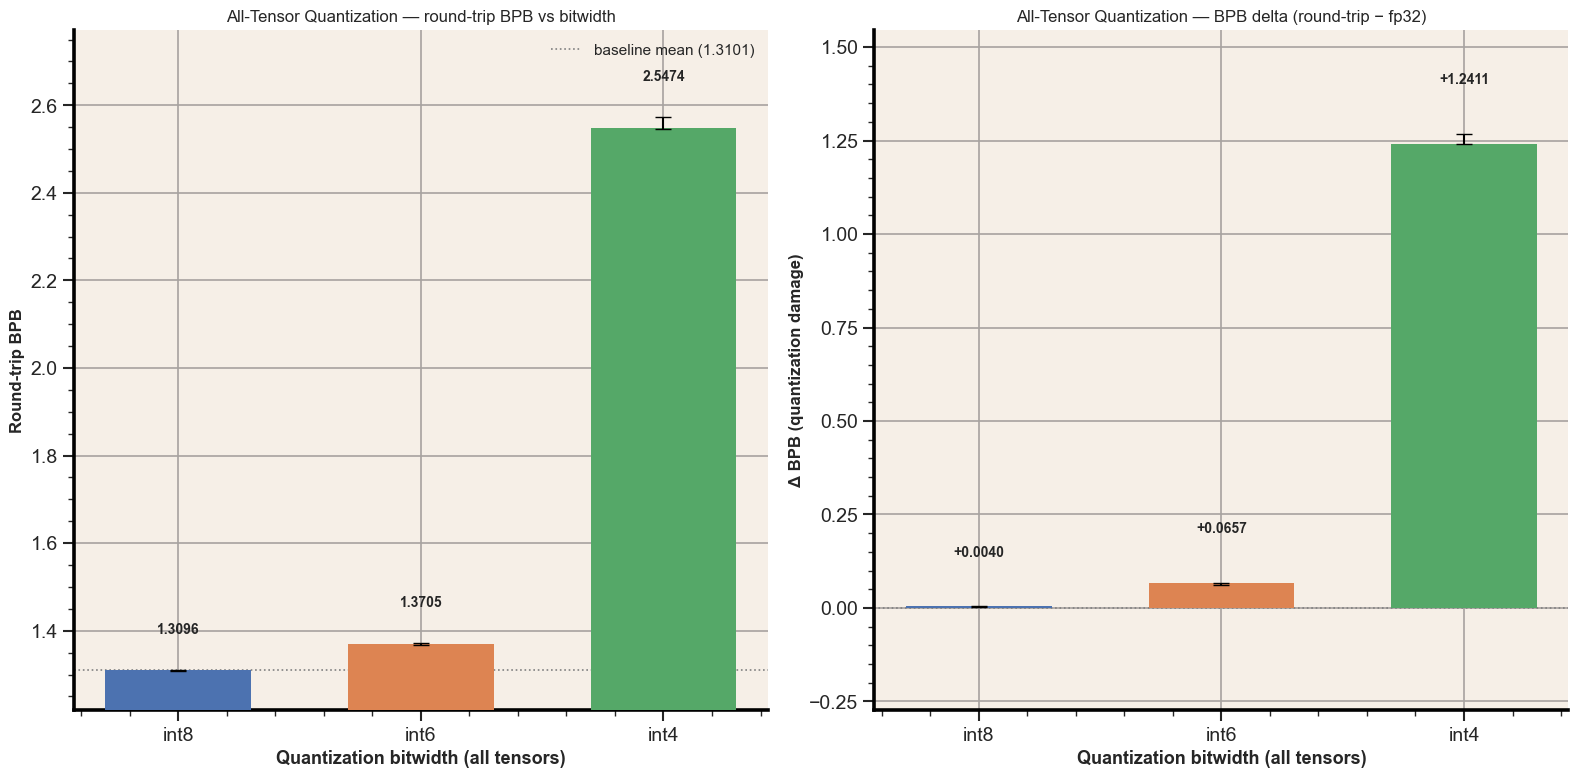

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

bits_vals = [b for b in BITS_ORDER if b in df_plot["matrix_quant_bits"].values]
sub = df_plot[df_plot["matrix_quant_bits"].isin(bits_vals)].set_index("matrix_quant_bits")

roundtrip = [sub.loc[b, "final_val_bpb_median"] for b in bits_vals]
roundtrip_q25 = [sub.loc[b, "final_val_bpb_q25"] for b in bits_vals]
roundtrip_q75 = [sub.loc[b, "final_val_bpb_q75"] for b in bits_vals]
roundtrip_err_low = [m - q for m, q in zip(roundtrip, roundtrip_q25)]
roundtrip_err_high = [q - m for m, q in zip(roundtrip, roundtrip_q75)]

deltas = [sub.loc[b, "delta_bpb_median"] for b in bits_vals]
delta_q25 = [sub.loc[b, "delta_bpb_q25"] for b in bits_vals]
delta_q75 = [sub.loc[b, "delta_bpb_q75"] for b in bits_vals]
delta_err_low = [m - q for m, q in zip(deltas, delta_q25)]
delta_err_high = [q - m for m, q in zip(deltas, delta_q75)]

colors = [BITS_COLORS[b] for b in bits_vals]
x = np.arange(len(bits_vals))

# Dynamic text offsets scaled to each subplot's spread
roundtrip_span = max(roundtrip_q75) - min(roundtrip_q25) if len(roundtrip_q75) else 0.0
roundtrip_pad = max(0.0003, 0.06 * roundtrip_span)

delta_span = max(delta_q75) - min(delta_q25) if len(delta_q75) else 0.0
delta_pad = max(0.0003, 0.10 * delta_span)

# --- Round-trip BPB ---
ax = axes[0]
ax.bar(x, roundtrip, color=colors, width=0.6, zorder=3)
ax.errorbar(
    x,
    roundtrip,
    yerr=[roundtrip_err_low, roundtrip_err_high],
    fmt="none",
    ecolor="black",
    elinewidth=1.5,
    capsize=6,
    zorder=4,
)

for i, bpb in enumerate(roundtrip):
    y = bpb + roundtrip_err_high[i] + roundtrip_pad
    ax.text(i, y, f"{bpb:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":", label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth (all tensors)", fontsize=13, fontweight="bold")
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("All-Tensor Quantization — round-trip BPB vs bitwidth", fontsize=12)
ax.legend(fontsize=11)

roundtrip_min = min(v - e for v, e in zip(roundtrip, roundtrip_err_low))
roundtrip_max = max(v + e for v, e in zip(roundtrip, roundtrip_err_high))
ax.set_ylim(roundtrip_min - roundtrip_pad * 1.2, roundtrip_max + roundtrip_pad * 2.6)

# --- Delta (quantization damage) ---
ax = axes[1]
ax.bar(x, deltas, color=colors, width=0.6, zorder=3)
ax.errorbar(
    x,
    deltas,
    yerr=[delta_err_low, delta_err_high],
    fmt="none",
    ecolor="black",
    elinewidth=1.5,
    capsize=6,
    zorder=4,
)

for i, d in enumerate(deltas):
    if d >= 0:
        y = d + delta_err_high[i] + delta_pad
        va = "bottom"
    else:
        y = d - delta_err_low[i] - delta_pad
        va = "top"
    ax.text(i, y, f"{d:+.4f}", ha="center", va=va, fontsize=10, fontweight="bold")

ax.axhline(0.0, color="grey", linewidth=1.2, linestyle=":")
ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth (all tensors)", fontsize=13, fontweight="bold")
ax.set_ylabel("Δ BPB (quantization damage)", fontsize=12)
ax.set_title("All-Tensor Quantization — BPB delta (round-trip − fp32)", fontsize=12)

delta_min = min(v - e for v, e in zip(deltas, delta_err_low))
delta_max = max(v + e for v, e in zip(deltas, delta_err_high))
ax.set_ylim(delta_min - delta_pad * 2.2, delta_max + delta_pad * 2.2)

plt.tight_layout(pad=1.5)
plt.show()

### Comparison: all-tensor vs 2D-only quantization

This section compares the results of quantizing all tensors vs only quantizing 2D matrices (from the previous ablation), to measure the marginal impact of also quantizing the small/control tensors.

In [15]:
# Fetch 2D-only ablation results for comparison
ABL_2D_PREFIX = "golf_2d_matrices_quantization_ablation"

abl_2d_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL_2D_PREFIX}"}},
))

rows_2d = []
for run in abl_2d_runs:
    s = run.summary._json_dict
    cfg = run.config
    bits = cfg.get("matrix_quant_bits", 8)
    rows_2d.append({
        "matrix_quant_bits": bits,
        "final_val_bpb": s.get("final_val_bpb"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df_2d = pd.DataFrame(rows_2d)

df_2d_plot = (
    df_2d.groupby("matrix_quant_bits", as_index=False)
    .agg(
        quant_file_bytes_median=("quant_file_bytes", "median"),
        quant_file_bytes_q25=("quant_file_bytes", lambda x: x.quantile(0.25)),
        quant_file_bytes_q75=("quant_file_bytes", lambda x: x.quantile(0.75)),
        final_val_bpb_median=("final_val_bpb", "median"),
        final_val_bpb_q25=("final_val_bpb", lambda x: x.quantile(0.25)),
        final_val_bpb_q75=("final_val_bpb", lambda x: x.quantile(0.75)),
    )
    .assign(bits_order=lambda d: d["matrix_quant_bits"].map({v: i for i, v in enumerate(BITS_ORDER)}))
    .sort_values("bits_order")
    .reset_index(drop=True)
    .drop(columns="bits_order")
)

df_2d_plot

,matrix_quant_bits,quant_file_bytes_median,quant_file_bytes_q25,quant_file_bytes_q75,final_val_bpb_median,final_val_bpb_q25,final_val_bpb_q75
0,8,15775590.0,15772238.0,15782993.5,1.310132,1.309636,1.310895
1,6,11903307.0,11899702.5,11904365.5,1.364526,1.363507,1.365434
2,4,7846052.0,7844017.0,7847021.5,2.245742,2.230646,2.252598


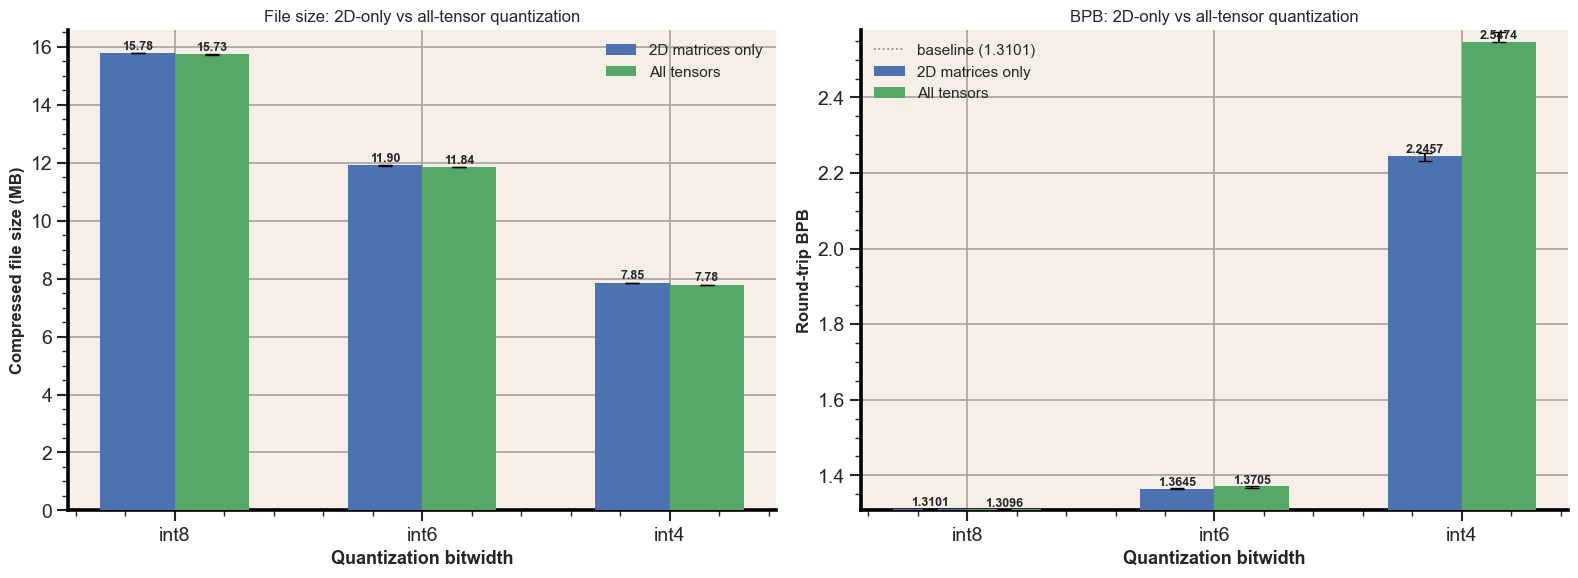

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bits_vals = [
    b
    for b in BITS_ORDER
    if b in df_plot["matrix_quant_bits"].values and b in df_2d_plot["matrix_quant_bits"].values
]

sub_2d = df_2d_plot[df_2d_plot["matrix_quant_bits"].isin(bits_vals)].set_index("matrix_quant_bits")
sub_all = df_plot[df_plot["matrix_quant_bits"].isin(bits_vals)].set_index("matrix_quant_bits")

x = np.arange(len(bits_vals))
width = 0.3

# --- File size comparison ---
ax = axes[0]
size_2d = [sub_2d.loc[b, "quant_file_bytes_median"] / 1e6 for b in bits_vals]
size_2d_q25 = [sub_2d.loc[b, "quant_file_bytes_q25"] / 1e6 for b in bits_vals]
size_2d_q75 = [sub_2d.loc[b, "quant_file_bytes_q75"] / 1e6 for b in bits_vals]
size_2d_err_low = [m - q for m, q in zip(size_2d, size_2d_q25)]
size_2d_err_high = [q - m for m, q in zip(size_2d, size_2d_q75)]

size_all = [sub_all.loc[b, "quant_file_bytes_median"] / 1e6 for b in bits_vals]
size_all_q25 = [sub_all.loc[b, "quant_file_bytes_q25"] / 1e6 for b in bits_vals]
size_all_q75 = [sub_all.loc[b, "quant_file_bytes_q75"] / 1e6 for b in bits_vals]
size_all_err_low = [m - q for m, q in zip(size_all, size_all_q25)]
size_all_err_high = [q - m for m, q in zip(size_all, size_all_q75)]

bars1 = ax.bar(x - width / 2, size_2d, width, label="2D matrices only", color=PALETTE[0], zorder=3)
bars2 = ax.bar(x + width / 2, size_all, width, label="All tensors", color=PALETTE[2], zorder=3)

ax.errorbar(
    x - width / 2,
    size_2d,
    yerr=[size_2d_err_low, size_2d_err_high],
    fmt="none",
    ecolor="black",
    elinewidth=1.3,
    capsize=5,
    zorder=4,
)
ax.errorbar(
    x + width / 2,
    size_all,
    yerr=[size_all_err_low, size_all_err_high],
    fmt="none",
    ecolor="black",
    elinewidth=1.3,
    capsize=5,
    zorder=4,
)

for bar_group, sizes in [(bars1, size_2d), (bars2, size_all)]:
    for bar, mb in zip(bar_group, sizes):
        ax.text(bar.get_x() + bar.get_width() / 2, mb + 0.03, f"{mb:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Compressed file size (MB)", fontsize=12)
ax.set_title("File size: 2D-only vs all-tensor quantization", fontsize=12)
ax.legend(fontsize=11)

# --- BPB comparison ---
ax = axes[1]
bpb_2d = [sub_2d.loc[b, "final_val_bpb_median"] for b in bits_vals]
bpb_2d_q25 = [sub_2d.loc[b, "final_val_bpb_q25"] for b in bits_vals]
bpb_2d_q75 = [sub_2d.loc[b, "final_val_bpb_q75"] for b in bits_vals]
bpb_2d_err_low = [m - q for m, q in zip(bpb_2d, bpb_2d_q25)]
bpb_2d_err_high = [q - m for m, q in zip(bpb_2d, bpb_2d_q75)]

bpb_all = [sub_all.loc[b, "final_val_bpb_median"] for b in bits_vals]
bpb_all_q25 = [sub_all.loc[b, "final_val_bpb_q25"] for b in bits_vals]
bpb_all_q75 = [sub_all.loc[b, "final_val_bpb_q75"] for b in bits_vals]
bpb_all_err_low = [m - q for m, q in zip(bpb_all, bpb_all_q25)]
bpb_all_err_high = [q - m for m, q in zip(bpb_all, bpb_all_q75)]

bars1 = ax.bar(x - width / 2, bpb_2d, width, label="2D matrices only", color=PALETTE[0], zorder=3)
bars2 = ax.bar(x + width / 2, bpb_all, width, label="All tensors", color=PALETTE[2], zorder=3)

ax.errorbar(
    x - width / 2,
    bpb_2d,
    yerr=[bpb_2d_err_low, bpb_2d_err_high],
    fmt="none",
    ecolor="black",
    elinewidth=1.3,
    capsize=5,
    zorder=4,
)
ax.errorbar(
    x + width / 2,
    bpb_all,
    yerr=[bpb_all_err_low, bpb_all_err_high],
    fmt="none",
    ecolor="black",
    elinewidth=1.3,
    capsize=5,
    zorder=4,
)

for bar_group, bpbs in [(bars1, bpb_2d), (bars2, bpb_all)]:
    for bar, bpb in zip(bar_group, bpbs):
        ax.text(bar.get_x() + bar.get_width() / 2, bpb + 0.0003, f"{bpb:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":", label=f"baseline ({BASE_BPB_MEAN:.4f})")
ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("BPB: 2D-only vs all-tensor quantization", fontsize=12)
ax.legend(fontsize=11)

ymin = min(bpb_2d_q25 + bpb_all_q25) - 0.002
ymax = max(bpb_2d_q75 + bpb_all_q75) + 0.004
ax.set_ylim(ymin, ymax)

plt.tight_layout(pad=1.5)
plt.show()

### Summary table

In [17]:
rows_summary = [{
    "config": "Original baseline (3 seeds)",
    "scope": "2D only",
    "val_bpb": BASE_BPB_MEAN,
    "val_bpb_range": f"±{BASE_BPB_STD:.4f}",
    "Δ vs baseline": 0.0,
    "file_size_MB": BASE_SIZE_MEAN / 1e6,
}]

for b in BITS_ORDER:
    # 2D-only
    sub_2d = df_2d_plot[df_2d_plot["matrix_quant_bits"] == b]
    if not sub_2d.empty:
        row = sub_2d.iloc[0]
        rows_summary.append({
            "config": f"{BITS_LABELS[b]} — 2D only",
            "scope": "2D only",
            "val_bpb": row["final_val_bpb_median"],
            "val_bpb_range": f"[{row['final_val_bpb_q25']:.4f}, {row['final_val_bpb_q75']:.4f}]",
            "Δ vs baseline": row["final_val_bpb_median"] - BASE_BPB_MEAN,
            "file_size_MB": row["quant_file_bytes_median"] / 1e6,
        })

    # All tensors
    sub_all = df_plot[df_plot["matrix_quant_bits"] == b]
    if not sub_all.empty:
        row = sub_all.iloc[0]
        rows_summary.append({
            "config": f"{BITS_LABELS[b]} — all tensors",
            "scope": "all",
            "val_bpb": row["final_val_bpb_median"],
            "val_bpb_range": f"[{row['final_val_bpb_q25']:.4f}, {row['final_val_bpb_q75']:.4f}]",
            "Δ vs baseline": row["final_val_bpb_median"] - BASE_BPB_MEAN,
            "file_size_MB": row["quant_file_bytes_median"] / 1e6,
        })

df_summary = pd.DataFrame(rows_summary)
df_summary["val_bpb"] = df_summary["val_bpb"].map(lambda x: f"{x:.4f}")
df_summary["Δ vs baseline"] = df_summary["Δ vs baseline"].map(lambda x: f"{x:+.4f}")
df_summary["file_size_MB"] = df_summary["file_size_MB"].map(lambda x: f"{x:.2f}")

print(df_summary.drop(columns="scope").to_string(index=False))

# Conclusion
print("\n" + "=" * 60)
if not df_plot.empty and not df_2d_plot.empty:
    for b in BITS_ORDER:
        sub_2d = df_2d_plot[df_2d_plot["matrix_quant_bits"] == b]
        sub_all = df_plot[df_plot["matrix_quant_bits"] == b]
        if not sub_2d.empty and not sub_all.empty:
            row_2d = sub_2d.iloc[0]
            row_all = sub_all.iloc[0]
            size_diff = (row_2d["quant_file_bytes_median"] - row_all["quant_file_bytes_median"]) / 1e3
            bpb_diff = row_all["final_val_bpb_median"] - row_2d["final_val_bpb_median"]
            print(f"{BITS_LABELS[b]}: quantizing small tensors saves {size_diff:.1f} KB "
                  f"but costs {bpb_diff:+.4f} BPB")

                     config val_bpb    val_bpb_range Δ vs baseline file_size_MB
Original baseline (3 seeds)  1.3101          ±0.0013       +0.0000        15.78
             int8 — 2D only  1.3101 [1.3096, 1.3109]       +0.0000        15.78
         int8 — all tensors  1.3096 [1.3090, 1.3103]       -0.0005        15.73
             int6 — 2D only  1.3645 [1.3635, 1.3654]       +0.0544        11.90
         int6 — all tensors  1.3705 [1.3676, 1.3715]       +0.0604        11.84
             int4 — 2D only  2.2457 [2.2306, 2.2526]       +0.9356         7.85
         int4 — all tensors  2.5474 [2.5465, 2.5742]       +1.2373         7.78

int8: quantizing small tensors saves 44.3 KB but costs -0.0005 BPB
int6: quantizing small tensors saves 62.0 KB but costs +0.0060 BPB
int4: quantizing small tensors saves 65.0 KB but costs +0.3016 BPB
